# 01 — Explore LoCoMo Dataset

Load and inspect the LoCoMo dataset. Understand the conversation structure, QA annotation format, and evidence turn mappings.

In [1]:
import sys
from pathlib import Path

# Resolve project root regardless of where Jupyter was launched from
_root = Path.cwd()
if not (_root / 'src').exists():
    _root = _root.parent
sys.path.insert(0, str(_root / 'src'))

from ingestor import load_locomo, get_stats

In [2]:
# Load dataset
conversations = load_locomo(_root / 'data' / 'locomo10.json')
print()
print('=== Dataset Stats ===')
stats = get_stats(conversations)

Loaded 10 conversations from c:\Users\evag3\Desktop\code\semantic-caching\data\locomo10.json

=== Dataset Stats ===
  num_conversations: 10
  total_turns: 5882
  total_qa_pairs: 1986
  avg_turns_per_conversation: 588.2


In [3]:
# Inspect a single conversation
conv = conversations[0]
print(f'Session: {conv.session_id}')
print(f'Turns: {len(conv.turns)}')
print(f'QA pairs: {len(conv.qa_pairs)}')
print()
print('--- First 5 turns ---')
for t in conv.turns[:5]:
    print(f'  [{t.turn_id}] {t.speaker}: {t.text[:100]}')

print()
print('--- First 3 QA pairs ---')
for qa in conv.qa_pairs[:3]:
    print(f'  Q: {qa.question}')
    print(f'  A: {qa.answer}')
    print(f'  Evidence turns: {qa.evidence_turn_ids}')
    print()

Session: conv-26
Turns: 419
QA pairs: 199

--- First 5 turns ---
  [0] Caroline: Hey Mel! Good to see you! How have you been?
  [1] Melanie: Hey Caroline! Good to see you! I'm swamped with the kids & work. What's up with you? Anything new?
  [2] Caroline: I went to a LGBTQ support group yesterday and it was so powerful.
  [3] Melanie: Wow, that's cool, Caroline! What happened that was so awesome? Did you hear any inspiring stories?
  [4] Caroline: The transgender stories were so inspiring! I was so happy and thankful for all the support.

--- First 3 QA pairs ---
  Q: When did Caroline go to the LGBTQ support group?
  A: 7 May 2023
  Evidence turns: [2]

  Q: When did Melanie paint a sunrise?
  A: 2022
  Evidence turns: [11]

  Q: What fields would Caroline be likely to pursue in her educaton?
  A: Psychology, counseling certification
  Evidence turns: [8, 10]



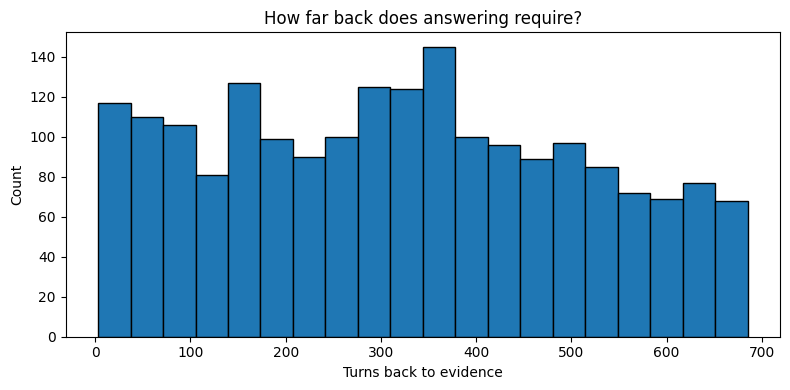

Median lookback: 319 turns


In [4]:
# Distribution of evidence turn distances (how far back does answering require?)
import matplotlib.pyplot as plt

evidence_distances = []
for conv in conversations:
    for qa in conv.qa_pairs:
        if qa.evidence_turn_ids:
            max_turn = max(t.turn_id for t in conv.turns)
            min_evidence = min(qa.evidence_turn_ids)
            evidence_distances.append(max_turn - min_evidence)

plt.figure(figsize=(8, 4))
plt.hist(evidence_distances, bins=20, edgecolor='black')
plt.xlabel('Turns back to evidence')
plt.ylabel('Count')
plt.title('How far back does answering require?')
plt.tight_layout()
plt.savefig(_root / 'results' / 'evidence_distance_dist.png', dpi=100)
plt.show()
print(f'Median lookback: {sorted(evidence_distances)[len(evidence_distances)//2]} turns')

In [5]:
# QA category distribution
from collections import Counter

categories = [
    qa.category
    for conv in conversations
    for qa in conv.qa_pairs
    if qa.category
]

if categories:
    cat_counts = Counter(categories)
    print('QA categories:')
    for cat, count in cat_counts.most_common():
        print(f'  {cat}: {count}')
else:
    print('No category annotations found')

QA categories:
  4: 841
  5: 446
  2: 321
  1: 282
  3: 96
